In [1]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

X = load_iris().data                 # 특성 4개 (=4차원)
pca = PCA(n_components=2)             # 2차원으로 줄이기
X_2d = pca.fit_transform(X)
print('줄인 뒤 모양:', X_2d.shape)
print('남긴 정보 비율:', pca.explained_variance_ratio_.round(2))

줄인 뒤 모양: (150, 2)
남긴 정보 비율: [0.92 0.05]


In [10]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = load_breast_cancer().data                 # 특성 30개 (=30차원)
X_s = StandardScaler().fit_transform(X)        # PCA는 분산 기준이라 스케일링

pca = PCA().fit(X_s)                            # 전체 주성분 구하기
cum = np.cumsum(pca.explained_variance_ratio_) # 정보 누적 합
n95 = int(np.argmax(cum >= 0.95)) + 1
print('정보 95%를 지키는 데 필요한 축 수:', n95, '(전체 30개 중)')

정보 95%를 지키는 데 필요한 축 수: 10 (전체 30개 중)


In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 공개 미러 URL로 바로 불러오기 (UCI 'Wine Quality')
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')   # 세미콜론으로 구분
df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [12]:
X = df.drop(columns='quality')                     # 품질(정답)만 빼고 특성 11개
X_s = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_s)                  # 11차원 -> 2차원
print('2축이 지킨 정보:', pca.explained_variance_ratio_.sum().round(2))

2축이 지킨 정보: 0.46


In [13]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 공개 미러 URL로 바로 불러오기 (UCI 'Wine Quality')
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df_3 = pd.read_csv(url, sep=';')   # 세미콜론으로 구분

X3 = df_3.drop(columns='quality')                        # 와인 성분 13개 (단위가 제각각)
X3_s = StandardScaler().fit_transform(X3)     # 같은 잣대로 맞추기 (거리 기반이라 필수)

pca = PCA(n_components=2)             # 2차원으로 줄이기
X_3d = pca.fit_transform(X3)

km = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = km.fit_predict(X3)

print('무리별 개수:', np.bincount(labels))
print('실루엣 점수:', round(silhouette_score(X_3d, labels), 3))

무리별 개수: [546 241 812]
실루엣 점수: 0.531


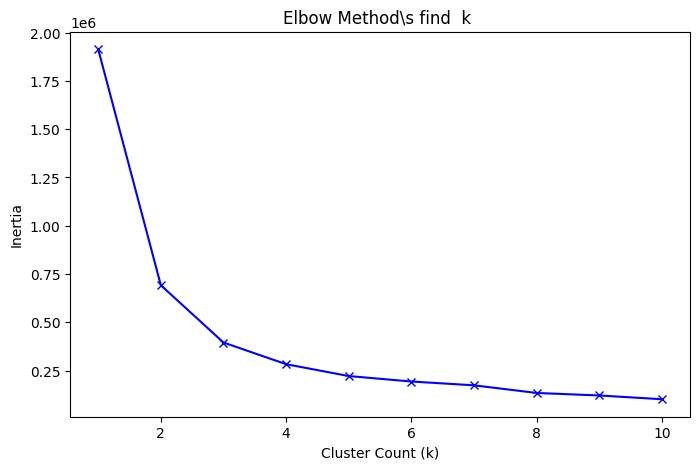

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# 적절한 k 찾기 (Elbow Method)
inertia = []    # 각 k 값에 대한 군집 내 거리 제곱합(Inertia)을 저장할 리스트
K = range(1,11) # K 범위 (1 - 10) 클러스터(군집그룹) 개수

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42) # 클러스터 개수를 k로 지정
    kmeans.fit(X3)  # 훈련 데이터로 학습 수행
    inertia.append(kmeans.inertia_) # 각 k에 대한 Inertia(거리 제곱합) 저장

# Elbow 그래프 시각화
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Cluster Count (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method\s find  k ')
plt.show()